In [1]:
from google.colab import files

files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ayanwap7/rice-image-dataset-train-test-split

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ayanwap7/rice-image-dataset-train-test-split
License(s): unknown
100% 220M/220M [00:02<00:00, 68.5MB/s]
100% 220M/220M [00:02<00:00, 77.3MB/s]


In [2]:
!unzip -qq rice-image-dataset-train-test-split.zip

In [3]:
import os

rice = 'Rice_Image_Dataset/'
train_dir = os.path.join(rice, 'train')
test_dir = os.path.join(rice, 'test')

classes = os.listdir(test_dir)
total = 0

for name_class in classes:
  class_path = os.path.join(test_dir, name_class)
  total_images = len(os.listdir(class_path))
  print(f"{class_path} : {total_images}")
  total += total_images

print(total)
list_rice = os.listdir(test_dir)

Rice_Image_Dataset/test/Arborio : 3000
Rice_Image_Dataset/test/Ipsala : 3000
Rice_Image_Dataset/test/Jasmine : 3000
Rice_Image_Dataset/test/Basmati : 3000
Rice_Image_Dataset/test/Karacadag : 3000
15000


In [4]:
print(list_rice)

['Arborio', 'Ipsala', 'Jasmine', 'Basmati', 'Karacadag']


In [5]:
class_rice = len(list_rice)
shape = 150,150
batch_size = 256

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    rescale=1./255,
    validation_split=0.15
)

Test_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
train_generator = Train_datagen.flow_from_directory(
    train_dir,
    target_size=shape,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True,
    subset="training"
)

validation_generator = Train_datagen.flow_from_directory(
    train_dir,
    target_size=shape,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False,
    subset="validation"
)

test_generator = Test_datagen.flow_from_directory(
    test_dir,
    target_size=shape,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 51000 images belonging to 5 classes.
Found 9000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.


In [8]:
import tensorflow as tf

accuracy_threshold = 0.95
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('accuracy') >= accuracy_threshold and logs.get('val_accuracy') >= accuracy_threshold:
            print(f'\nEpoch {epoch}: Training dihentikan karena akurasi mencapai {accuracy_threshold * 100}%')
            self.model.stop_training = True

callbacks = myCallback()

In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Conv2D, Dropout, BatchNormalization
from tensorflow.keras.layers import MaxPooling2D, Flatten, Dense
from tensorflow.keras import models

base_model = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(150, 150, 3)))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = Dropout(0.4)(x)
x = BatchNormalization()(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = Dropout(0.4)(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten(name="flatten")(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.25)(x)
x = BatchNormalization()(x)
x = Dense(64, activation="relu")(x)
x = Dense(class_rice, activation='softmax')(x)

model = models.Model(base_model.input, x)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

<ipython-input-9-0c25a67e0448>:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(150, 150, 3)))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 150, 150, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 75, 75, 32)     │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 75, 75, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 75, 75, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 75, 75, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 75, 75, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 75, 75, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 75, 75, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 75, 75, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 75, 75, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 75, 75, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 75, 75, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 77, 77, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 38, 38, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise_BN 

 Total params: 3,284,613 (12.53 MB)

 Trainable params: 1,025,733 (3.91 MB)

 Non-trainable params: 2,258,880 (8.62 MB)

In [15]:
epochs = 2

hist = model.fit(train_generator,
              epochs=epochs,
              steps_per_epoch = train_generator.samples // batch_size,
              validation_data = validation_generator,
              validation_steps = validation_generator.samples // batch_size,
              verbose = 1)

Epoch 1/2
199/199 ━━━━━━━━━━━━━━━━━━━━ 2026s 10s/step - accuracy: 0.9772 - loss: 0.0690 - val_accuracy: 0.9829 - val_loss: 0.0532
Epoch 2/2
  1/199 ━━━━━━━━━━━━━━━━━━━━ 21:14 6s/step - accuracy: 0.9727 - loss: 0.0862

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


199/199 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.9727 - loss: 0.0862 - val_accuracy: 0.9843 - val_loss: 0.0462


In [16]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc * 100:.2f}%')

59/59 ━━━━━━━━━━━━━━━━━━━━ 384s 6s/step - accuracy: 0.9832 - loss: 0.0523
Test Accuracy: 98.45%


In [17]:
hist.history['test_accuracy'] = test_acc
hist.history['test_loss'] = test_loss

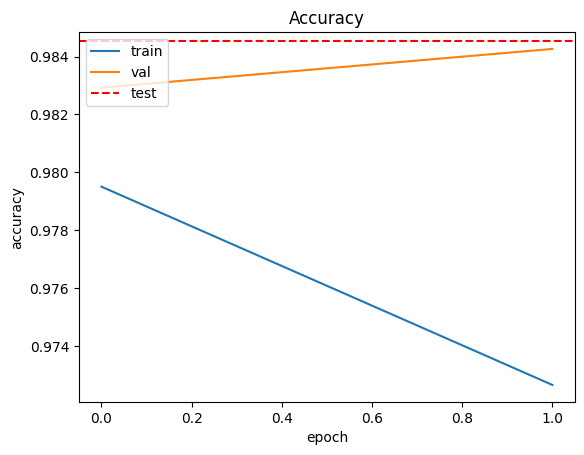

In [18]:
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.axhline(y=test_acc, color='r', linestyle='--')
plt.title('Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val', 'test'], loc='upper left')
plt.show()

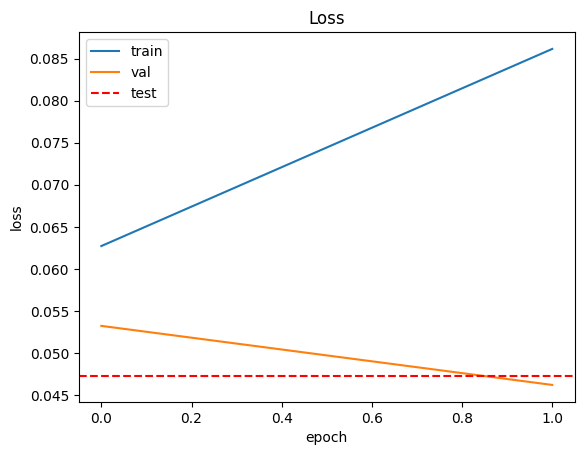

In [19]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.axhline(y=test_loss, color='r', linestyle='--')
plt.title('Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val', 'test'], loc='upper left')
plt.show()

In [20]:
import pathlib
os.mkdir("model_save")

export_dir = 'model_save/'
tf.saved_model.save(model, export_dir)

In [21]:
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('rice.tflite')
tflite_model_file.write_bytes(tflite_model)

197816

In [22]:
os.system("pip install tensorflowjs")
os.makedirs("tfjs_model", exist_ok=True)
os.system("tensorflowjs_converter --input_format=tf_saved_model model_save tfjs_model")

0

In [23]:
labels = list(train_generator.class_indices.keys())

with open("label.txt", "w") as f:
    for i, label in enumerate(labels):
        f.write(f"{i} {label}\n")